# Price and Volume Signals in U.S. Stocks and ETFs

This notebook runs the final DATA 498D capstone pipeline. The main question is whether historical price and volume features can predict which assets will rank in the top 20% of future five-day returns.

## 1. Run the Reproducible Pipeline

The pipeline loads the Kaggle files from `data/raw`, filters to a liquid stock/ETF universe, engineers lagged features, trains models, runs a simple backtest, and exports report-ready figures.

In [2]:
import os
import sys

project_root = "/Users/liboyang/Desktop/498/stock-signal-capstone"
os.chdir(project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

print("Current folder:", os.getcwd())

Current folder: /Users/liboyang/Desktop/498/stock-signal-capstone


In [3]:
from src.run_pipeline import run

run(
    raw_dir='data/raw',
    output_dir='.',
    ticker_file='config/liquid_universe.txt',
    use_sample_if_missing=False,
    save_panels=False,
)

Loaded raw rows: 1,412,252
Clean rows: 1,345,128; assets retained: 230
Feature engineering complete.
Modeling rows: 679,803
EDA figures complete.
Models complete.
Backtest and figures complete.
Pipeline complete.
Assets retained: 230
Modeling rows: 679,803
                 model  mean_5d_return  annualized_return  annualized_volatility  sharpe_ratio  max_drawdown  win_rate
      market_benchmark        0.002209           0.117641               0.114479      1.027617     -0.464524  0.612273
hist_gradient_boosting        0.002716           0.146460               0.178654      0.819799     -0.806681  0.549512
   logistic_regression        0.001795           0.094612               0.165073      0.573153     -0.786706  0.543933
   short_term_reversal        0.001396           0.072841               0.162855      0.447273     -0.762548  0.517434
      momentum_top_21d        0.000128           0.006479               0.124499      0.052039     -0.652181  0.527197


## 2. Model Metrics

In [4]:
import pandas as pd

metrics = pd.read_csv('data/processed/model_metrics.csv')
metrics

,model,split,accuracy_at_median_cutoff,average_precision,roc_auc
0,logistic_regression,validation,0.564001,0.293413,0.640439
1,logistic_regression,test,0.558936,0.286221,0.628114
2,hist_gradient_boosting,validation,0.567614,0.298711,0.644722
3,hist_gradient_boosting,test,0.562865,0.293936,0.634607


## 3. Strategy Performance

In [5]:
performance = pd.read_csv('data/processed/strategy_performance_summary.csv')
performance

,model,mean_5d_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,win_rate
0,market_benchmark,0.002209,0.117641,0.114479,1.027617,-0.464524,0.612273
1,hist_gradient_boosting,0.002716,0.146460,0.178654,0.819799,-0.806681,0.549512
2,logistic_regression,0.001795,0.094612,0.165073,0.573153,-0.786706,0.543933
3,short_term_reversal,0.001396,0.072841,0.162855,0.447273,-0.762548,0.517434
4,momentum_top_21d,0.000128,0.006479,0.124499,0.052039,-0.652181,0.527197


## 4. Momentum Quintile Test

In [6]:
momentum = pd.read_csv('data/processed/momentum_quintile_summary.csv')
momentum

,momentum_quintile,mean_future_5d_return
0,Q1 losers,0.003238
1,Q2,0.002662
2,Q3,0.002697
3,Q4,0.002660
4,Q5 winners,0.002165


## 5. Feature Importance

In [7]:
importance = pd.read_csv('data/processed/feature_importance.csv')
importance.head(15)

,model,feature,importance
0,logistic_regression,market_volatility_21d,0.249455
1,logistic_regression,drawdown_63d,0.239436
2,logistic_regression,volatility_21d,0.214344
3,logistic_regression,price_vs_ma_63d,0.153026
4,logistic_regression,daily_range,0.122629
5,logistic_regression,volatility_63d,0.085236
6,logistic_regression,dollar_volume_log,0.072470
7,logistic_regression,ret_63d,0.042635
8,logistic_regression,volatility_5d,0.041628
9,logistic_regression,excess_ret_5d,0.041023


## 6. Report Figures

The files below are exported by the pipeline and can be inserted into the final report or presentation.

figures/eda_returns_distribution.png


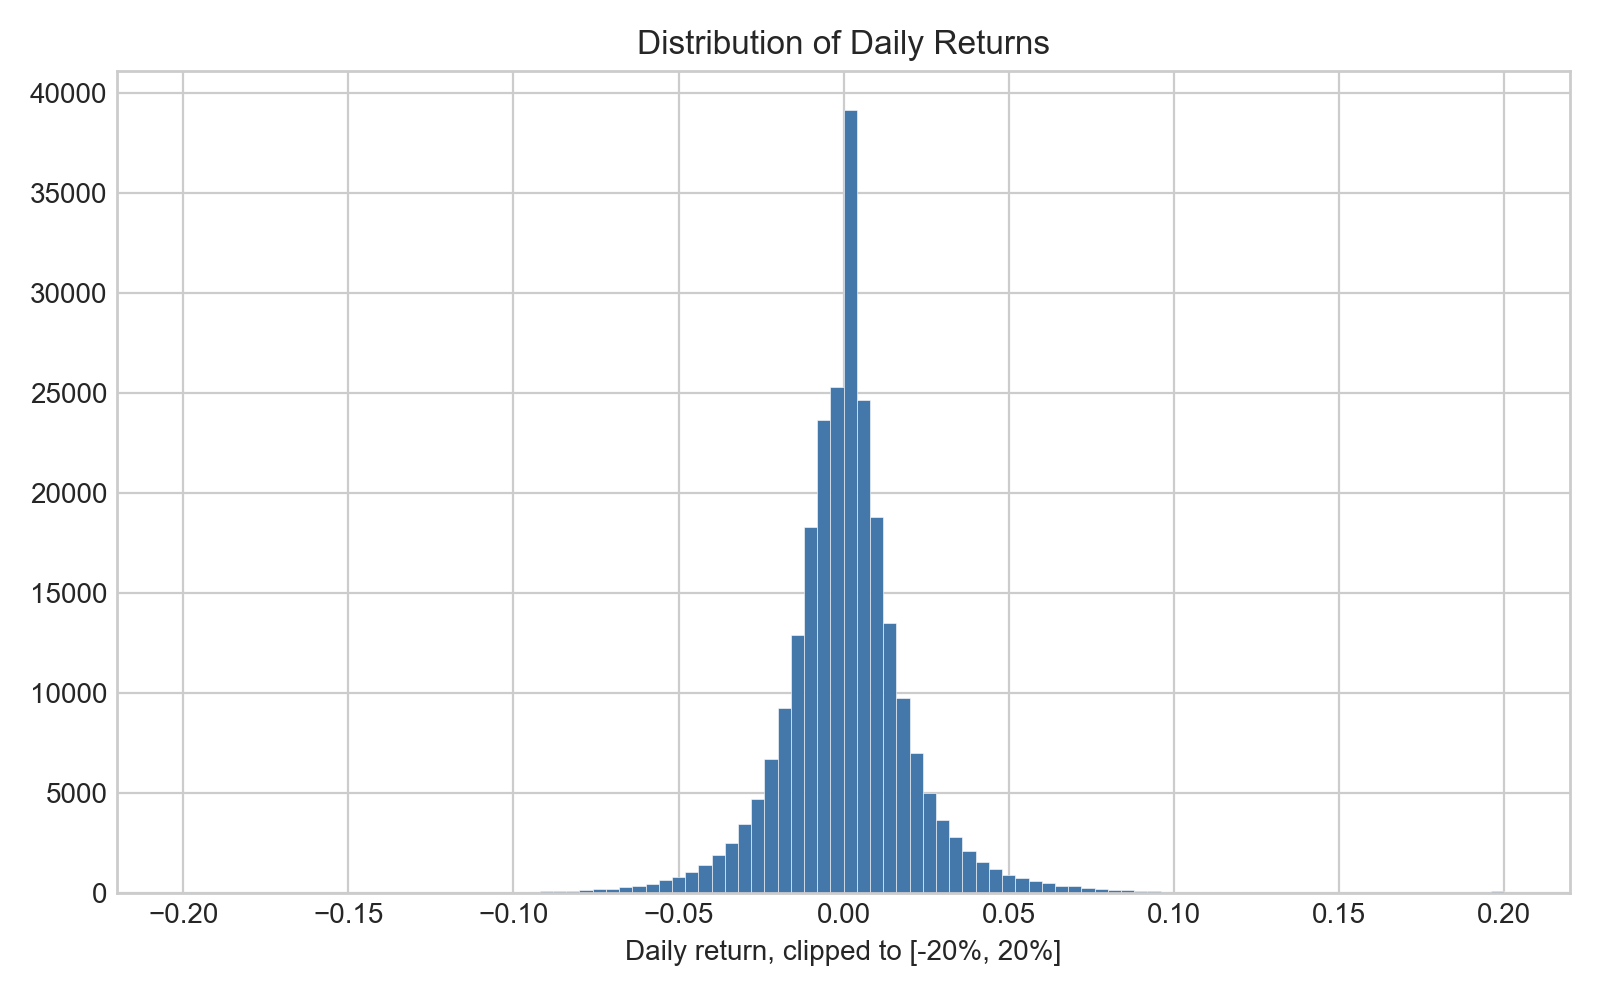

figures/momentum_quintiles.png


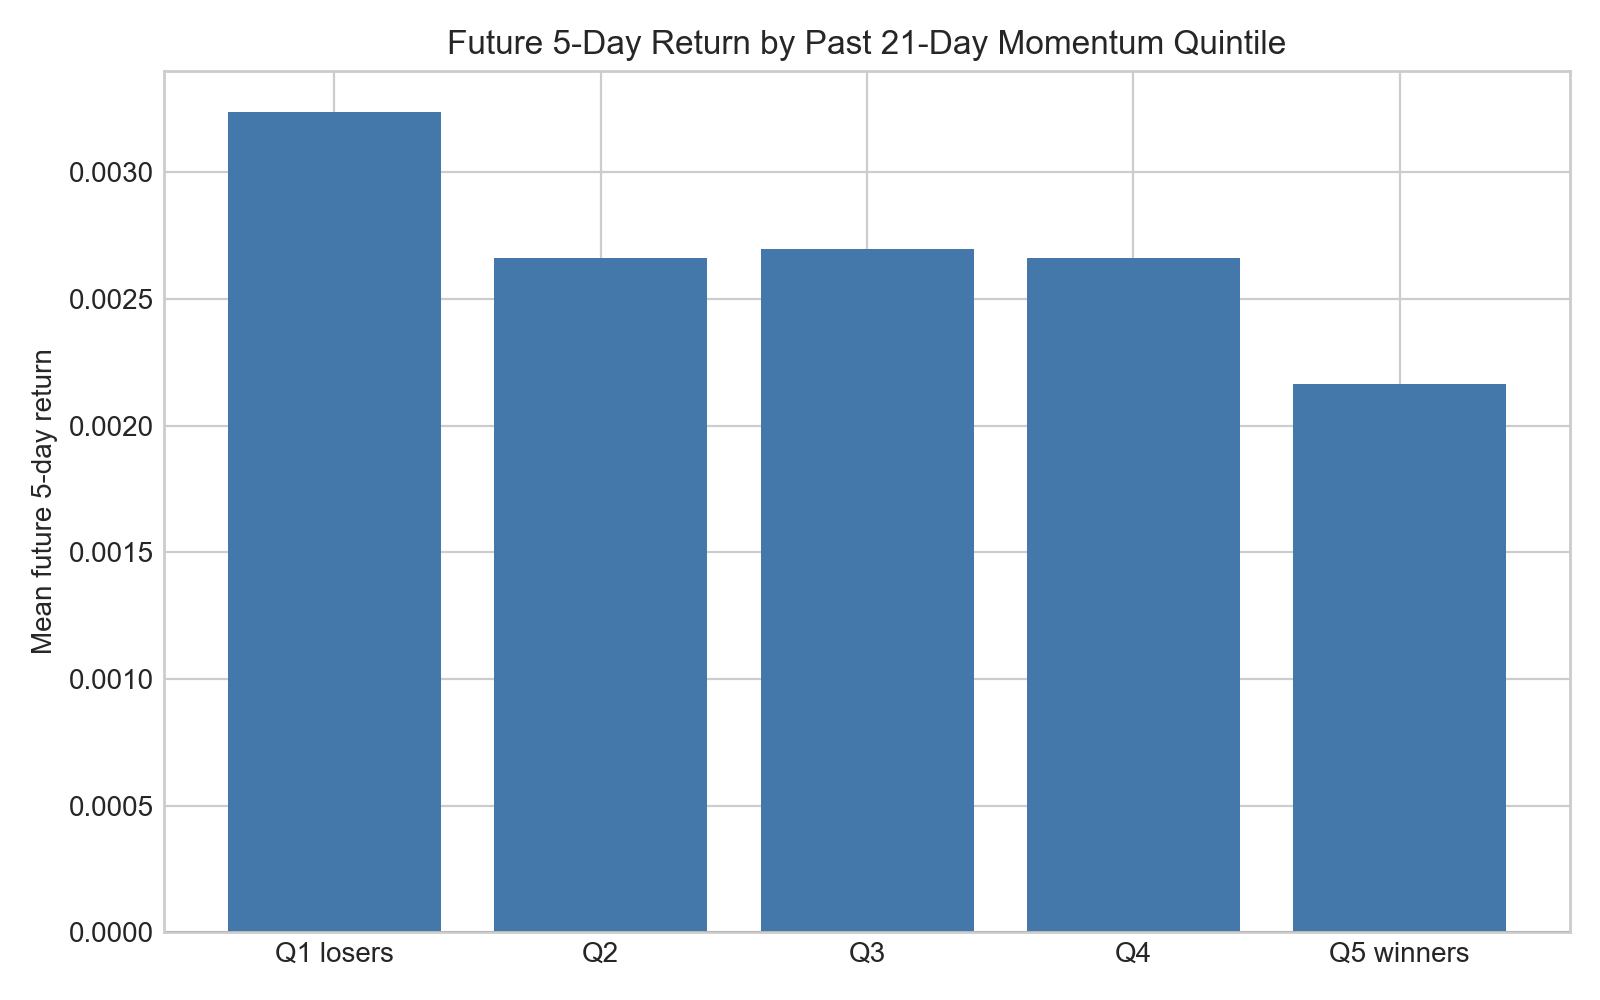

figures/model_comparison.png


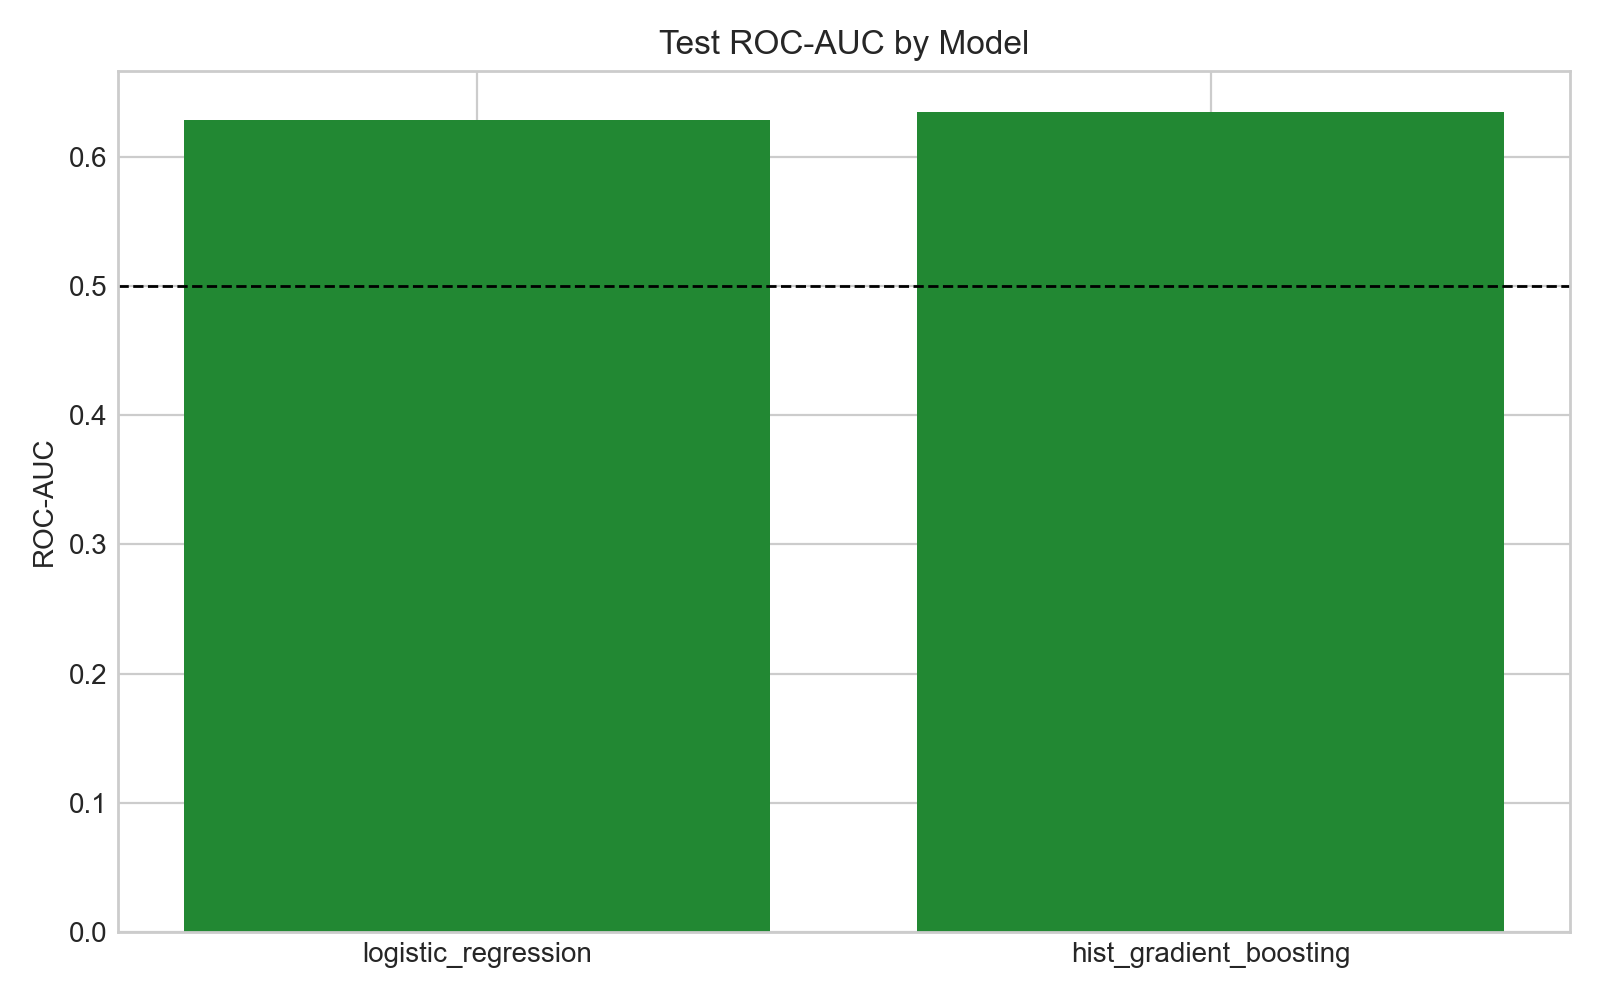

figures/backtest_cumulative_returns.png


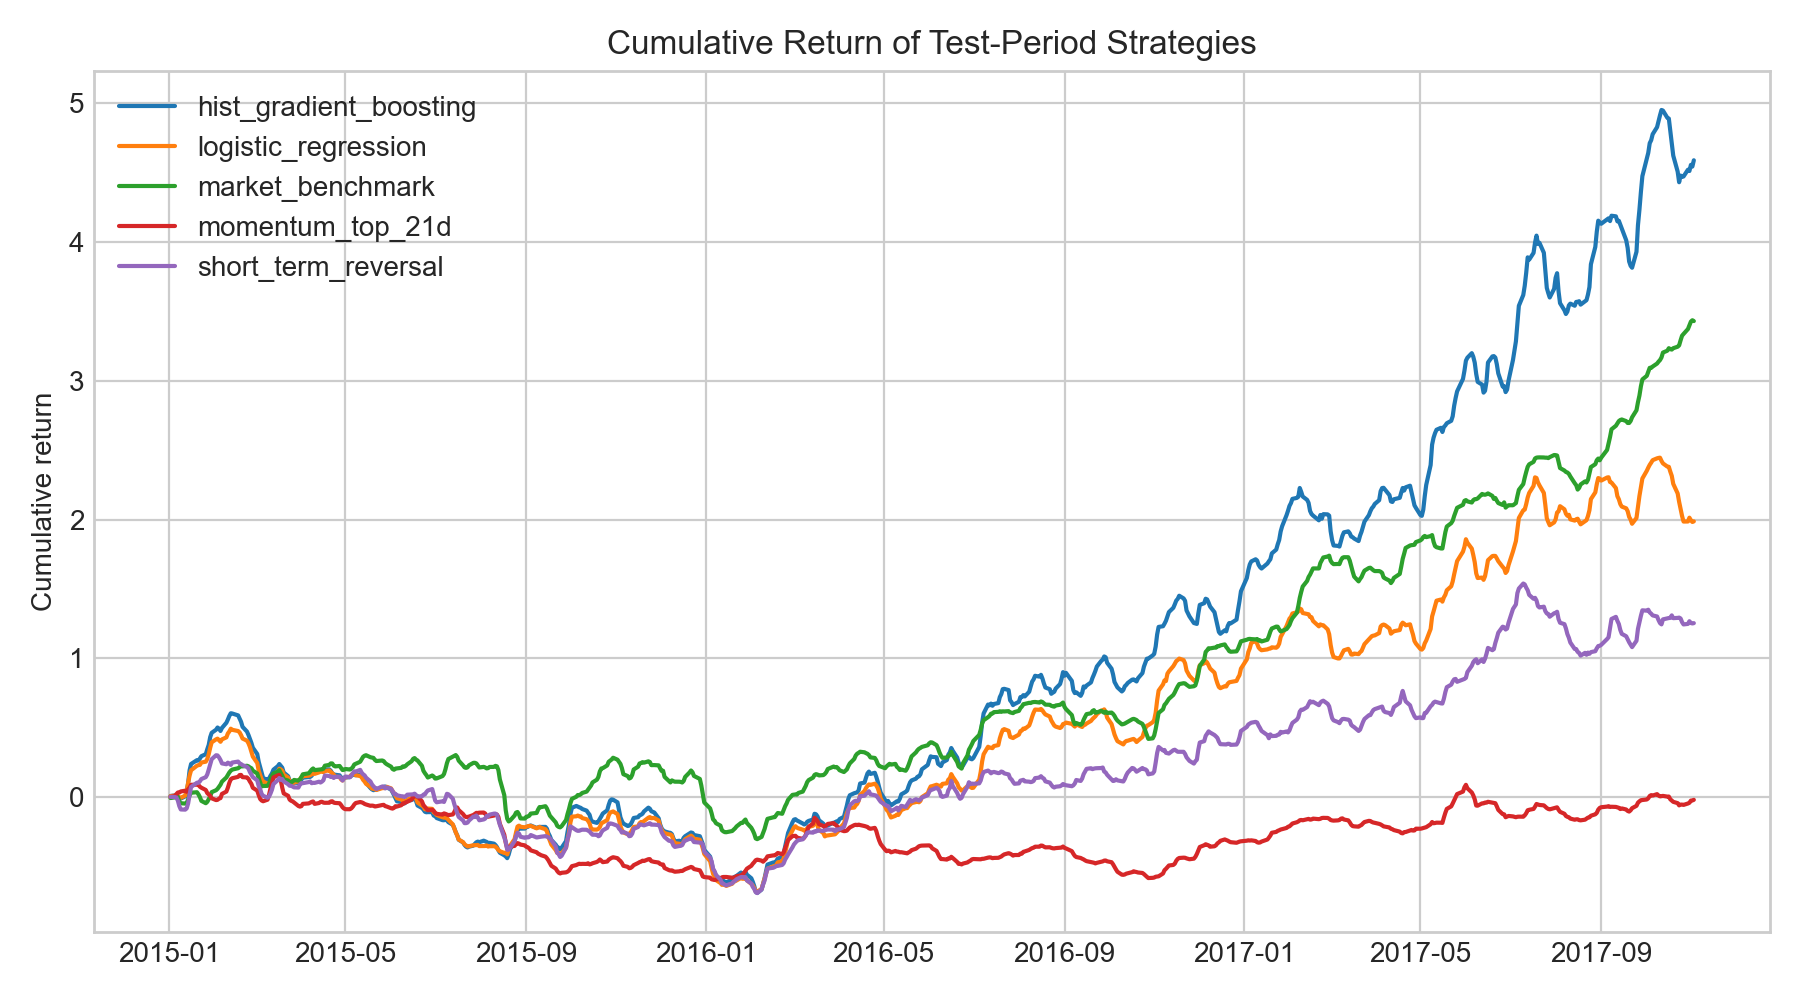

figures/feature_importance.png


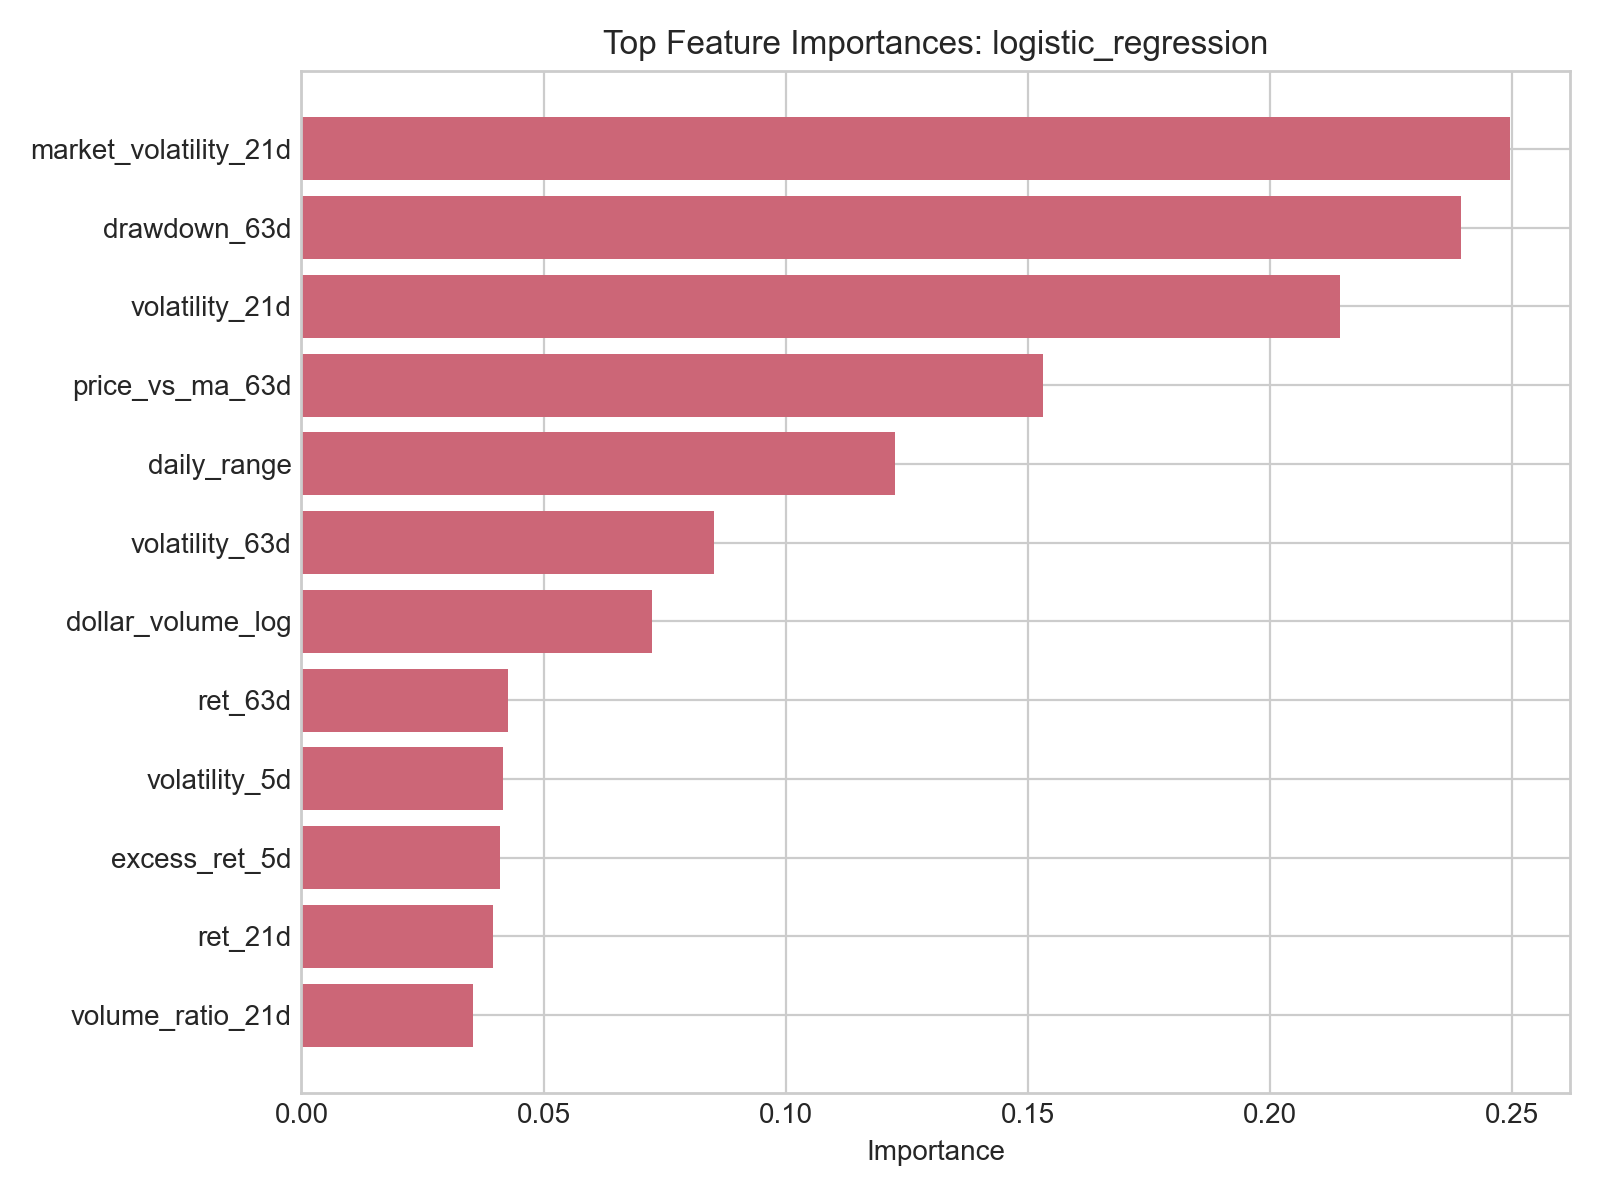

In [8]:
from IPython.display import Image, display

for path in [
    'figures/eda_returns_distribution.png',
    'figures/momentum_quintiles.png',
    'figures/model_comparison.png',
    'figures/backtest_cumulative_returns.png',
    'figures/feature_importance.png',
]:
    print(path)
    display(Image(filename=path))